# Data Preprocessing
---

In [ ]:
!pip -q install pandas numpy matplotlib seaborn statsmodels scipy beautifulsoup4 tqdm plotly PyPDF2 pdfplumber nbformat geopandas folium fpdf fpdf2

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from dataclasses import dataclass
import argparse
from pathlib import Path
import re
import glob
from bs4 import BeautifulSoup
from tqdm import tqdm
from PyPDF2 import PdfReader
import pdfplumber
import warnings
import plotly.express as px
import folium
import math
from fpdf import FPDF
from fpdf.enums import XPos, YPos
from datetime import datetime


In [2]:
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)


warnings.simplefilter("ignore", category=FutureWarning)

from component.data_transformer_html import generate_csvs_from_folder
from component.csv_combiner import combine_csvs_from_folder
from component.pdf_processor import process_all_pdfs
from component.popularity import (
    prepare_popularity_data,
    clean_numeric,
    food_popularity,
    net_consumption,
    leftover_rate,
    get_net_consumption_by_school,
    get_leftover_rate_by_school
)
from component.optimization import (
    prepare_map_data_from_coordinates,
    prepare_optimization_data,
    run_meal_optimization,
    run_meal_optimization_ilp,
    generate_item_breakdown,
    run_size_based_optimization,
    run_proportional_monthly_optimization_ilp,
    analyze_annual_budget,
    calculate_actual_annual_cost,
    prepare_savings_analysis_df,
    analyze_savings_by_school_size,
    prepare_regional_map_data,
    generate_fcps_region_choropleth
)
from component.optimization_milk import (
    prepare_optimization_data_m,
    run_meal_optimization_m,
    run_meal_optimization_ilp_m,
    generate_item_breakdown_m,
    run_size_based_optimization_m,
    run_monthly_meal_optimization_m,
    run_proportional_monthly_optimization_m
)

### Data Transformer (HTML)

In [3]:
folder_path = "../data/FairfaxCounty/May 2025 Lunch production records/May 2025 Lunch production records"
output_dir = "../data/preprocessed-data/Lunch production"
generate_csvs_from_folder(folder_path, output_dir)

folder_path = "../data/FairfaxCounty/May 2025 Breakfast production records/May 2025 Breakfast production records"
output_dir = "../data/preprocessed-data/Breakfast production"
generate_csvs_from_folder(folder_path, output_dir)


Output directory: ../data/preprocessed-data/Lunch production
Found 21 HTML files in ../data/FairfaxCounty/May 2025 Lunch production records/May 2025 Lunch production records
Generating CSV: ../data/preprocessed-data/Lunch production/5.08.25.csv
Processing file: ../data/FairfaxCounty/May 2025 Lunch production records/May 2025 Lunch production records/5.08.25.html
Filters section found: Date Range...
Inferred date from file name: 5/08/2025
Using date: 5/08/2025
Found 188 school sections in ../data/FairfaxCounty/May 2025 Lunch production records/May 2025 Lunch production records/5.08.25.html
Processing school: Aldrin Elementary
Parsing table for school: Aldrin Elementary
Detected 22 columns: ['Identifier', 'Name', 'Planned', 'Offered', 'Served', 'Discarded', 'Subtotal', 'Left Over', 'Production Cost', 'Reimbursable', 'Non-Reimbursable', 'Total', 'Reimbursable', 'Non-Reimbursable', 'Total', 'Cost', 'Total', 'Percent of Offered', 'Cost', 'Total', 'Percent of Offered', 'Cost']
Created DataFr

### CSV Combiner (HTML)

In [4]:
# Breakfast
input_dir = '../data/preprocessed-data/Breakfast production'
output_file = '../data/preprocessed-data/breakfast_combined.csv'
sort_columns = ['School_Name', 'Date', 'Identifier']

combine_csvs_from_folder(input_dir, output_file, sort_columns)


Found 21 CSV files in ../data/preprocessed-data/Breakfast production
Reading ../data/preprocessed-data/Breakfast production/5.13.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.29.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.27.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.23.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.07.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.19.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.15.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.21.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.09.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.05.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.28.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.12.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.02.25.csv
Reading ../data/preprocessed-data/Breakfast production/5.06.

In [5]:
# Lunch
input_dir = '../data/preprocessed-data/Lunch production'
output_file = '../data/preprocessed-data/lunch_combined.csv'
sort_columns = ['School_Name', 'Date', 'Identifier']

combine_csvs_from_folder(input_dir, output_file, sort_columns)

Found 21 CSV files in ../data/preprocessed-data/Lunch production
Reading ../data/preprocessed-data/Lunch production/5.13.25.csv
Reading ../data/preprocessed-data/Lunch production/5.29.25.csv
Reading ../data/preprocessed-data/Lunch production/5.27.25.csv
Reading ../data/preprocessed-data/Lunch production/5.23.25.csv
Reading ../data/preprocessed-data/Lunch production/5.07.25.csv
Reading ../data/preprocessed-data/Lunch production/5.19.25.csv
Reading ../data/preprocessed-data/Lunch production/5.15.25.csv
Reading ../data/preprocessed-data/Lunch production/5.21.25.csv
Reading ../data/preprocessed-data/Lunch production/5.09.25.csv
Reading ../data/preprocessed-data/Lunch production/5.05.25.csv
Reading ../data/preprocessed-data/Lunch production/5.28.25.csv
Reading ../data/preprocessed-data/Lunch production/5.12.25.csv
Reading ../data/preprocessed-data/Lunch production/5.01.25 lunch.csv
Reading ../data/preprocessed-data/Lunch production/5.02.25.csv
Reading ../data/preprocessed-data/Lunch product

### PDF Processing

In [ ]:
# Define the input and output paths relative to the notebook's location
pdf_folder = "../data/FairfaxCounty/Item Sales Reports - Mar May 2025/Item Sales Reports - Mar May 2025"
output_file = "../data/preprocessed-data/sales.csv"

# Call the function to process all PDFs and generate the combined sales.csv
process_all_pdfs(pdf_folder, output_file)

---
# Data Cleaning and EDA
---

In [3]:
# Set plot style
sns.set(style="whitegrid")

### EDA of Breakfast Data: breakfast_combined

In [4]:
# Load your dataset
dfb = pd.read_csv('../data/preprocessed-data/breakfast_combined.csv', low_memory=False)
dfb['School_Name'] = dfb['School_Name'].str.lower()
dfb.columns = dfb.columns.str.lower()
dfb.head()

,school_name,date,identifier,name,planned_reimbursable,planned_non-reimbursable,planned_total,offered_reimbursable,offered_non-reimbursable,offered_total,served_reimbursable,served_non-reimbursable,served_total,discarded_total,discarded_cost,subtotal_cost,left_over_total,left_over_percent_of_offered,left_over_cost,production_cost_total
0,aldrin elementary,5/01/2025,10041,Mini Maple Pancakes (Package),57,0,57,59,56,0,56,$21.84,0,0.00%,$0.00,$21.84,3,5.08%,$1.17,$23.01
1,aldrin elementary,5/01/2025,20001,1% White Milk (Each),33,0,33,37,34,0,34,$12.24,0,0.00%,$0.00,$12.24,3,8.11%,$1.08,$13.32
2,aldrin elementary,5/01/2025,20017,Orange (6 Slices per 1/2 cup),51,0,51,55,53,0,53,$18.02,0,0.00%,$0.00,$18.02,2,3.64%,$0.68,$18.70
3,aldrin elementary,5/01/2025,20038,Fat Free White Milk (Each),11,0,11,15,13,0,13,$4.29,0,0.00%,$0.00,$4.29,2,13.33%,$0.66,$4.95
4,aldrin elementary,5/01/2025,30003,Honey Cheerios Cereal (Each),10,0,10,10,7,0,7,$4.13,0,0.00%,$0.00,$4.13,3,30.00%,$1.77,$5.90


In [5]:
# Show basic info
print("Shape of dataset:", dfb.shape)
print("\nData types:\n", dfb.dtypes)

Shape of dataset: (55646, 20)

Data types:
 school_name                     object
date                            object
identifier                      object
name                            object
planned_reimbursable             int64
planned_non-reimbursable         int64
planned_total                    int64
offered_reimbursable             int64
offered_non-reimbursable         int64
offered_total                    int64
served_reimbursable              int64
served_non-reimbursable         object
served_total                     int64
discarded_total                 object
discarded_cost                  object
subtotal_cost                   object
left_over_total                  int64
left_over_percent_of_offered    object
left_over_cost                  object
production_cost_total           object
dtype: object


In [6]:
# show statistics
dfb.describe()

,planned_reimbursable,planned_non-reimbursable,planned_total,offered_reimbursable,offered_non-reimbursable,offered_total,served_reimbursable,served_total,left_over_total
count,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000
mean,33.435431,0.081300,33.516731,45.235812,35.404432,0.507817,35.912249,0.129282,9.195450
std,63.312415,1.042007,63.355922,68.060557,58.877480,3.289844,59.028820,1.021627,21.275619
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,2.000000,10.000000,5.000000,0.000000,6.000000,0.000000,0.000000
50%,14.000000,0.000000,14.000000,24.000000,16.000000,0.000000,17.000000,0.000000,3.000000
75%,40.000000,0.000000,40.000000,51.000000,40.000000,0.000000,41.000000,0.000000,10.000000
max,4561.000000,63.000000,4561.000000,2245.000000,2216.000000,165.000000,2216.000000,53.000000,985.000000


In [7]:
# Check for missing values
print("\nMissing values:\n", dfb.isnull().sum())


Missing values:
 school_name                     0
date                            0
identifier                      0
name                            0
planned_reimbursable            0
planned_non-reimbursable        0
planned_total                   0
offered_reimbursable            0
offered_non-reimbursable        0
offered_total                   0
served_reimbursable             0
served_non-reimbursable         0
served_total                    0
discarded_total                 0
discarded_cost                  0
subtotal_cost                   0
left_over_total                 0
left_over_percent_of_offered    0
left_over_cost                  0
production_cost_total           0
dtype: int64


In [8]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfb.duplicated().sum())


Number of duplicate rows: 0


In [9]:
# overview look at food names
food_cat = dfb.groupby('name')['planned_total'].sum()

summary_b = food_cat.sort_values(ascending=False)
sumb_10 = summary_b.head(10
)
print(sumb_10)

name
Apple Juice (Each)                                     453973
Orange Tangerine Juice (Each)                          248470
1% White Milk (Each)                                   211190
Mini Maple Pancakes (Package)                          140160
Red Delicious Apple (Each - serving)                    89769
Honey Cheerios Cereal (Each)                            76478
Cinnamon Toast Crunch Cereal, 25% Less Sugar (Each)     71307
Cinnamon Chex Cereal (Each)                             67403
Fat Free White Milk (Each)                              64173
Blueberry Chex Cereal (Each)                            59862
Name: planned_total, dtype: int64


### EDA of Lunch Data: lunch_combined

In [10]:
# Load your dataset
dfl = pd.read_csv('../data/preprocessed-data/lunch_combined.csv', low_memory=False)
dfl['School_Name'] = dfl['School_Name'].str.lower()
dfl.columns = dfl.columns.str.lower()
dfl.head()

,school_name,date,identifier,name,planned_reimbursable,planned_non-reimbursable,planned_total,offered_reimbursable,offered_non-reimbursable,offered_total,served_reimbursable,served_non-reimbursable,served_total,discarded_total,discarded_cost,subtotal_cost,left_over_total,left_over_percent_of_offered,left_over_cost,production_cost_total
0,aldrin elementary,5/01/2025,10044,Soft Pretzel (1 pretzel),15,0,15,31,27,0,27,$5.94,0,0.00%,$0.00,$5.94,4,12.90%,$0.88,$6.82
1,aldrin elementary,5/01/2025,10062,Corn (1/4 cup (thawed)),92,0,92,155,152,0,152,$16.72,0,0.00%,$0.00,$16.72,3,1.94%,$0.33,$17.05
2,aldrin elementary,5/01/2025,20001,1% White Milk (Each),44,0,44,120,43,0,43,$15.48,0,0.00%,$0.00,$15.48,77,64.17%,$27.72,$43.20
3,aldrin elementary,5/01/2025,20002,Fat Free Chocolate Milk (Each),133,0,133,155,131,0,131,$45.85,0,0.00%,$0.00,$45.85,24,15.48%,$8.40,$54.25
4,aldrin elementary,5/01/2025,20016,String Cheese (Each),2,0,2,5,2,0,2,$0.44,0,0.00%,$0.00,$0.44,3,60.00%,$0.66,$1.10


In [11]:
# Show basic info
print("Shape of dataset:", dfl.shape)
print("\nData types:\n", dfl.dtypes)

Shape of dataset: (136111, 20)

Data types:
 school_name                     object
date                            object
identifier                      object
name                            object
planned_reimbursable             int64
planned_non-reimbursable         int64
planned_total                    int64
offered_reimbursable             int64
offered_non-reimbursable         int64
offered_total                    int64
served_reimbursable              int64
served_non-reimbursable         object
served_total                     int64
discarded_total                 object
discarded_cost                  object
subtotal_cost                   object
left_over_total                  int64
left_over_percent_of_offered    object
left_over_cost                  object
production_cost_total           object
dtype: object


In [12]:
# show statistics
dfl.describe()

,planned_reimbursable,planned_non-reimbursable,planned_total,offered_reimbursable,offered_non-reimbursable,offered_total,served_reimbursable,served_total,left_over_total
count,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000
mean,60.195950,0.631389,60.827339,87.493884,70.779614,2.375583,73.155197,0.548001,13.793103
std,203.746777,9.022324,204.262536,177.571425,162.788814,14.983064,163.544555,3.501302,43.741154
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,13.000000,6.000000,0.000000,9.000000,0.000000,0.000000
50%,20.000000,0.000000,20.000000,42.000000,30.000000,0.000000,32.000000,0.000000,1.000000
75%,70.000000,0.000000,70.000000,100.000000,87.000000,0.000000,90.000000,0.000000,10.000000
max,54100.000000,500.000000,54100.000000,40030.000000,39957.000000,630.000000,39957.000000,525.000000,1286.000000


In [13]:
# Check for missing values
print("\nMissing values:\n", dfl.isnull().sum())


Missing values:
 school_name                     0
date                            0
identifier                      0
name                            0
planned_reimbursable            0
planned_non-reimbursable        0
planned_total                   0
offered_reimbursable            0
offered_non-reimbursable        0
offered_total                   0
served_reimbursable             0
served_non-reimbursable         0
served_total                    0
discarded_total                 0
discarded_cost                  0
subtotal_cost                   0
left_over_total                 0
left_over_percent_of_offered    0
left_over_cost                  0
production_cost_total           0
dtype: int64


In [14]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfl.duplicated().sum())


Number of duplicate rows: 0


In [15]:
# overview look at food names
food_cat = dfl.groupby('name')['planned_total'].sum()

summary_l = food_cat.sort_values(ascending=False)
suml_10 = summary_l.head(10
)
print(suml_10)

name
Fat Free Chocolate Milk (Each)          966354
Lettuce Blend Salad Mix (1/2 cup)       622525
Ketchup Packet (Packet)                 600672
Ranch Dressing (1 ounce)                361148
PB&J Power Pack (Power Packs)           337854
1% White Milk (Each)                    249208
Manager's Vegetable Choice (1/4 cup)    235047
Cheese Pizza (Slice)                    198151
Mayonnaise Packet (Packet)              193858
Chicken Tenders (3 tenders)             174341
Name: planned_total, dtype: int64


### EDA of Sales

In [16]:
# Load your dataset
dfs = pd.read_csv('../data/preprocessed-data/sales.csv')
dfs.head()

,time_of_day,school_code,school_name,date,item,description,total,free_meals,reduced_price_meals,full_price_meals,adults,alac_student,alac_adult,earned_student,earned_adult,earned_alac_student,earned_alac_adult,adj_alac,adj_meal
0,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1146,CEREAL MEAL,10,2,0,8,0,0,0,0,0,0,0,0,0
1,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1170,MINI PANCAKES,32,2,0,30,0,0,0,0,0,0,0,0,0
2,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1310,ALC BREAKFAST ENTREE,8,0,0,0,0,8,0,0,0,0,0,0,0
3,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1405,EGG & CHEESE ON BISCUIT,2,0,0,2,0,0,0,0,0,0,0,0,0
4,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,151,CEREAL/ NO MILK,9,0,0,0,0,9,0,0,0,0,0,0,0


In [17]:
# Show basic info
print("Shape of dataset:", dfs.shape)
print("\nData types:\n", dfs.dtypes)

Shape of dataset: (224536, 19)

Data types:
 time_of_day            object
school_code             int64
school_name            object
date                   object
item                    int64
description            object
total                   int64
free_meals              int64
reduced_price_meals     int64
full_price_meals        int64
adults                  int64
alac_student            int64
alac_adult              int64
earned_student          int64
earned_adult            int64
earned_alac_student     int64
earned_alac_adult       int64
adj_alac                int64
adj_meal                int64
dtype: object


In [18]:
# show statistics
dfs.describe()

,school_code,item,total,free_meals,reduced_price_meals,full_price_meals,adults,alac_student,alac_adult,earned_student,earned_adult,earned_alac_student,earned_alac_adult,adj_alac,adj_meal
count,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.0
mean,221.613398,1245.693274,40.621615,15.044964,1.497666,11.708799,0.137043,12.225830,0.096283,0.001038,0.303288,0.003643,0.000334,0.000013,0.0
std,133.682146,909.230796,69.212535,40.143932,5.621533,27.997202,2.062739,41.665041,0.954267,0.052410,1.239649,0.189640,0.023019,0.003655,0.0
min,17.000000,1.000000,0.000000,-3.000000,-1.000000,-18.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,103.000000,717.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,206.000000,1136.000000,14.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,334.000000,1310.000000,46.000000,11.000000,1.000000,11.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
max,501.000000,3501.000000,955.000000,942.000000,801.000000,649.000000,267.000000,947.000000,43.000000,9.000000,37.000000,25.000000,5.000000,1.000000,0.0


In [19]:
# Check for missing values
print("\nMissing values:\n", dfs.isnull().sum())


Missing values:
 time_of_day            0
school_code            0
school_name            0
date                   0
item                   0
description            0
total                  0
free_meals             0
reduced_price_meals    0
full_price_meals       0
adults                 0
alac_student           0
alac_adult             0
earned_student         0
earned_adult           0
earned_alac_student    0
earned_alac_adult      0
adj_alac               0
adj_meal               0
dtype: int64


In [20]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfs.duplicated().sum())


Number of duplicate rows: 0


In [21]:
# Convert your datetime column
dfs['date'] = pd.to_datetime(dfs['date']) 

# Set datetime as index
dfs.set_index('date', inplace=True)

# Sort by date
dfs = dfs.sort_index()


C:\Users\kaoji\AppData\Local\Temp\ipykernel_28848\1267965289.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dfs['date'] = pd.to_datetime(dfs['date'])


In [22]:
# Check date range and frequency
print("Date Range:", dfs.index.min(), "to", dfs.index.max())
print("Frequency (inferred):", pd.infer_freq(dfs.index))

Date Range: 2025-03-03 00:00:00 to 2025-05-30 00:00:00
Frequency (inferred): None


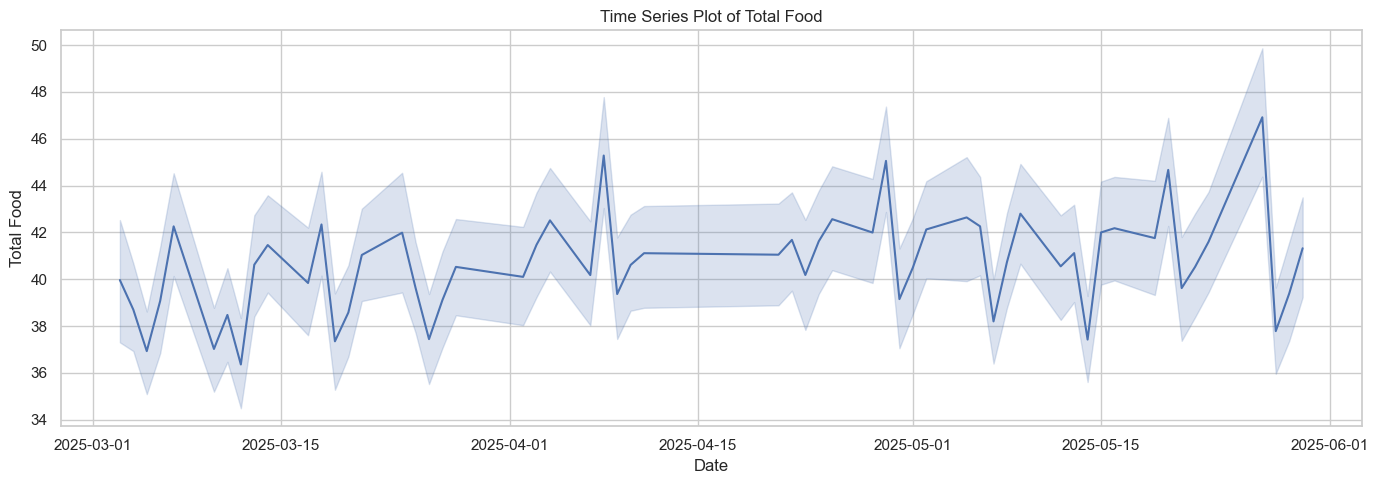

In [23]:
# Plot full time series for a numeric column
plt.figure(figsize=(14, 5))
sns.lineplot(data=dfs, x=dfs.index, y='total')
plt.title("Time Series Plot of Total Food")
plt.xlabel("Date")
plt.ylabel("Total Food")
plt.tight_layout()
plt.show()

---
# Food Popularity
---

In [7]:
breakfast_file = "../data/preprocessed-data/breakfast_combined.csv"
lunch_file = "../data/preprocessed-data/lunch_combined.csv"
sales_file = "../data/preprocessed-data/sales.csv"

bf_df, l_df, s_df = prepare_popularity_data(breakfast_file, lunch_file, sales_file)

num_cols = [
    "served_non-reimbursable", "discarded_total", "discarded_cost",
    "subtotal_cost", "left_over_percent_of_offered", "left_over_cost",
    "left_over_total", "production_cost_total"
]

if bf_df is not None:
    bf_df = clean_numeric(bf_df, num_cols)
if l_df is not None:
    l_df = clean_numeric(l_df, num_cols)

food_popularity(bf_df, l_df, s_df)

Top 10 Breakfast Items (by served_total):
                                                    served_reimbursable
name                                                                   
Apple Juice (Each)                                               422347
Orange Tangerine Juice (Each)                                    227110
Mini Maple Pancakes (Package)                                    196086
1% White Milk (Each)                                             189429
Bagel (Bagel)                                                     92610
Honey Cheerios Cereal (Each)                                      71032
Cream Cheese (Each)                                               70942
Red Delicious Apple (Each - serving)                              69694
Cinnamon Toast Crunch Cereal, 25% Less Sugar (E...                63964
Cinnamon Chex Cereal (Each)                                       59553

Top 10 Lunch Items (by served_total):
                                      served_reimbursab

In [8]:
# --- Run School-Level Analysis ---
# This assumes bf_df and l_df are loaded and cleaned from the cell above (c7d6f4e0)

print("Running school-level analysis...")

# --- Run Breakfast Calculations ---
breakfast_net_consumption_school = get_net_consumption_by_school(bf_df, 'Breakfast')
breakfast_leftover_rate_school = get_leftover_rate_by_school(bf_df, 'Breakfast')

# --- Run Lunch Calculations ---
lunch_net_consumption_school = get_net_consumption_by_school(l_df, 'Lunch')
lunch_leftover_rate_school = get_leftover_rate_by_school(l_df, 'Lunch')

# --- Save Results to CSV Files ---
print("\nSaving results to CSV files...")

# Use the relative paths from your notebook
output_path = '../data/preprocessed-data/'
breakfast_net_consumption_school.to_csv(output_path + 'breakfast_net_consumption_by_school.csv', index=False)
lunch_net_consumption_school.to_csv(output_path + 'lunch_net_consumption_by_school.csv', index=False)

breakfast_leftover_rate_school.to_csv(output_path + 'breakfast_leftover_rate_by_school.csv', index=False)
lunch_leftover_rate_school.to_csv(output_path + 'lunch_leftover_rate_by_school.csv', index=False)

print("Successfully created 4 CSV files in '../data/preprocessed-data/':")
print("- breakfast_net_consumption_by_school.csv")
print("- lunch_net_consumption_by_school.csv")
print("- breakfast_leftover_rate_by_school.csv")
print("- lunch_leftover_rate_by_school.csv")

Running school-level analysis...
Calculating Net Consumption Rate by Item and School for Breakfast...
Calculating Leftover Rate by Item and School for Breakfast...
Calculating Net Consumption Rate by Item and School for Lunch...
Calculating Leftover Rate by Item and School for Lunch...

Saving results to CSV files...
Successfully created 4 CSV files in '../data/preprocessed-data/':
- breakfast_net_consumption_by_school.csv
- lunch_net_consumption_by_school.csv
- breakfast_leftover_rate_by_school.csv
- lunch_leftover_rate_by_school.csv


In [9]:
net_consumption(bf_df, l_df)

=== NET CONSUMPTION POPULARITY RANKINGS ===

Top 15 Breakfast Items (by Net Consumption):
                                                    Net Consumption  \
name                                                                  
Apple Juice (Each)                                        422247.16   
Orange Tangerine Juice (Each)                             227001.49   
Mini Maple Pancakes (Package)                             195252.97   
1% White Milk (Each)                                      188965.25   
Bagel (Bagel)                                              91235.15   
Cream Cheese (Each)                                        70882.48   
Honey Cheerios Cereal (Each)                               70799.31   
Red Delicious Apple (Each - serving)                       69423.46   
Cinnamon Toast Crunch Cereal, 25% Less Sugar (E...         63588.42   
Cinnamon Chex Cereal (Each)                                59150.37   
Blueberry Chex Cereal (Each)                              

In [10]:
leftover_rate(bf_df, l_df)

=== LEFTOVER RATE RANKINGS ===

Top 15 Breakfast Items (Highest Leftover Rate - Most Waste):
                                                    Leftover Rate (%)  \
name                                                                    
Fat Free Chocolate Milk (Each)                                  98.83   
Cereal, Cinnamon Toasters, Malt-O-Meal, IW (Sub...              60.26   
Fat Free White Milk (Each)                                      53.49   
Cherry Flavored Dried Cranberries (Each)                        53.12   
Fat Free Unflavored Shelf-Stable Milk (Each)                    52.70   
Milk, Lactose Free,  Fat Free, Shelf-Stable (Each)              51.28   
Orange Flavored Dried Cranberries (Each)                        50.00   
Watermelon Flavored Dried Cranberries (2 Eaches)                48.05   
Assorted Cereal (Cereal Cup)                                    47.13   
Patty, Chicken, Breaded, WG (2 strips)                          46.88   
Frozen, Blueberries (1/2 cup)  

---
# Time Series Analysis


---
# Optimization
---

In [4]:
# Define file paths
breakfast_file = '../data/preprocessed-data/breakfast_combined.csv'
lunch_file = '../data/preprocessed-data/lunch_combined.csv'
student_counts_file = '../data/preprocessed-data/2022-2025 Fairfax County School Student Count.csv'

file_list = [breakfast_file, lunch_file]

# Prepare all data needed for the optimization models
opt_data = prepare_optimization_data(breakfast_file, lunch_file, student_counts_file)

--- Preparing Optimization Data ---
Data preparation complete.


In [5]:
output_file = "unit_costs.csv"

# Check if files exist
try:    
    for f in file_list:
        if not os.path.exists(f):
            print(f"Error: The file '{f}' was not found.")
            print("Please make sure the file is in the same directory as your notebook.")
            # Stop execution if a file is missing
            raise FileNotFoundError(f"{f} not found.")
            
    # Load the datasets into a list of DataFrames
    dataframes = []
    for f in file_list:
        dataframes.append(pd.read_csv(f, low_memory=False))
    
    # Combine the breakfast and lunch dataframes into one
    df_combined = pd.concat(dataframes, ignore_index=True)
    
    print(f"Loaded and combined {len(df_combined)} total rows from {len(file_list)} files.")
    
    # Select only the columns needed for this analysis
    relevant_cols = ['Name', 'Production_Cost_Total', 'Offered_Reimbursable']
    df_analysis = df_combined[relevant_cols].copy()

    # --- Data Cleaning ---
    
    # 1. Clean the 'Production_Cost_Total' column
    #    Remove '$' and ',' characters
    df_analysis.loc[:, 'Production_Cost_Total'] = df_analysis['Production_Cost_Total'].replace({'\$': '', ',': ''}, regex=True)
    #    Convert the column to a numeric (float) type
    df_analysis.loc[:, 'Production_Cost_Total'] = pd.to_numeric(df_analysis['Production_Cost_Total'], errors='coerce')
    
    # 2. Clean the 'Offered_Reimbursable' column
    #    Convert to numeric, just in case it's not already.
    df_analysis.loc[:, 'Offered_Reimbursable'] = pd.to_numeric(df_analysis['Offered_Reimbursable'], errors='coerce')
    
    # 3. Drop any rows where the key data is missing
    df_analysis.dropna(subset=['Name', 'Production_Cost_Total', 'Offered_Reimbursable'], inplace=True)

    # --- Aggregation and Calculation ---
    
    # Group by the food item 'Name' to handle duplicates
    df_grouped = df_analysis.groupby('Name')
    
    # Aggregate the data: sum up the total cost and total offered for each unique item
    print("Aggregating data for each unique food item...")
    df_agg = df_grouped.agg(
        Total_Production_Cost=('Production_Cost_Total', 'sum'),
        Total_Offered_Reimbursable=('Offered_Reimbursable', 'sum')
    ).reset_index()
    
    # Calculate the Unit Cost using your formula
    # (Total Production Cost / Total Offered Reimbursable)
    df_agg['Unit_Cost'] = df_agg['Total_Production_Cost'] / df_agg['Total_Offered_Reimbursable']
    
    # Handle any potential division by zero (which results in 'inf')
    # We replace infinity with NaN (Not a Number) to represent an undefined cost
    df_agg.replace([np.inf, -np.inf], np.nan, inplace=True)

    df_agg['Unit_Cost'] = df_agg['Unit_Cost'].round(2)
    
    # Select the final columns for the output CSV
    df_final = df_agg[['Name', 'Unit_Cost']]
    
    # --- Save to CSV ---
    
    # Save the results to the specified CSV file
    # float_format='%.4f' formats the unit cost to 4 decimal places for clarity
    df_final.to_csv(output_file, index=False, float_format='%.2f')
    
    print(f"\nSuccessfully created {output_file}.")
    print("Here's a preview of the calculated unit costs:")
    print(df_final.head())

except FileNotFoundError:
    pass  # The error message was already printed
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")

Loaded and combined 191757 total rows from 2 files.
Aggregating data for each unique food item...

Successfully created unit_costs.csv.
Here's a preview of the calculated unit costs:
                                        Name  Unit_Cost
0  -Peas and Diced Carrots, Frozen (1/2 cup)       0.00
1     1% Unflavored Shelf-Stable Milk (Each)       0.38
2                       1% White Milk (Each)       0.36
3             Alfredo & Basil Lasagna (Each)       1.26
4         Apple Berry Smoothie (8oz portion)       0.66


In [6]:
if opt_data:
    # Set up parameters
    total_budget = 139144760
    budget_per_school = total_budget / len(opt_data['schools'])
    school_budgets = {s: budget_per_school for s in opt_data['schools']}
    waste_penalty = [0.50, 1.00]

    daily_bounds = []
    for school in opt_data['schools']:
        for i in range(len(opt_data['meal_types'])):
            daily_bounds.append((opt_data['demand'][school][i] * 0.90, opt_data['demand'][school][i] * 1.10))

    # Run the optimization and generate the item breakdown
    results_df = run_meal_optimization(
        opt_data['schools'], opt_data['meal_types'], opt_data['meal_costs'], 
        opt_data['demand'], school_budgets, total_budget, waste_penalty, daily_bounds
    )
    generate_item_breakdown(results_df, opt_data['dfb'], opt_data['dfl'], '../data/school_food_item_optimization.csv')


--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $261136.18

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 290 units (Demand: 322, Prod. Bounds: 290-354)
    Lunch: 1317 units (Demand: 1463, Prod. Bounds: 1317-1609)
    School Total Cost: $657.94 (Budget: $732340.84)

  annandale high:
    Breakfast: 2396 units (Demand: 2662, Prod. Bounds: 2396-2928)
    Lunch: 6617 units (Demand: 7353, Prod. Bounds: 6617-8088)
    School Total Cost: $3696.09 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 1029 units (Demand: 1144, Prod. Bounds: 1029-1258)
    Lunch: 2219 units (Demand: 2466, Prod. Bounds: 2219-2712)
    School Total Cost: $1333.23 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 181 units (Demand: 202, Prod. Bounds: 181-221)
    Lunch: 871 units (Demand: 968, Prod. Bounds: 871-1064)
    School Total Cost: $430.65 (Budget: $732340.84)

  baileys lower e

In [7]:
if opt_data and opt_data['all_school_lists']:
    run_size_based_optimization(
        opt_data['schools'], opt_data['meal_types'], opt_data['meal_costs'],
        opt_data['demand'], {s: (139144760 / len(opt_data['schools'])) for s in opt_data['schools']}, 
        139144760, [0.50, 1.00], opt_data['all_school_lists']
    )

--- Starting Size-Based Optimization ---
Categorized 190 schools based on your lists.
Production bounds have been set based on custom school sizes.

--- Integer Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $266173.72

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 274 units (Demand: 322, Prod. Bounds: 273-370)
    Lunch: 1244 units (Demand: 1463, Prod. Bounds: 1243-1682)
    School Total Cost: $621.51 (Budget: $732340.84)

  annandale high:
    Breakfast: 2583 units (Demand: 2662, Prod. Bounds: 2582-2742)
    Lunch: 7133 units (Demand: 7353, Prod. Bounds: 7132-7573)
    School Total Cost: $3984.38 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 1030 units (Demand: 1144, Prod. Bounds: 1029-1258)
    Lunch: 2220 units (Demand: 2466, Prod. Bounds: 2219-2712)
    School Total Cost: $1334.06 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 172 units (Demand: 2

In [8]:
# Runs the daily Integer Linear Programming (ILP) model
if opt_data:
    # Set up the same daily parameters as the first model
    total_budget = 139144760
    budget_per_school = total_budget / len(opt_data['schools'])
    school_budgets = {s: budget_per_school for s in opt_data['schools']}
    waste_penalty = [0.50, 1.00]
    
    daily_bounds = []
    for school in opt_data['schools']:
        for i in range(len(opt_data['meal_types'])):
            daily_bounds.append((opt_data['demand'][school][i] * 0.90, opt_data['demand'][school][i] * 1.10))

    # Call the ILP function with all the required arguments
    ilp_results_df = run_meal_optimization_ilp(
        opt_data['schools'], opt_data['meal_types'], opt_data['meal_costs'], 
        opt_data['demand'], school_budgets, total_budget, waste_penalty, daily_bounds
    )
    
    # Generate a separate breakdown file for the ILP results
    generate_item_breakdown(ilp_results_df, opt_data['dfb'], opt_data['dfl'], '../data/school_food_item_optimization_ilp.csv')


--- Integer Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $261225.87

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 291 units (Demand: 322, Prod. Bounds: 290-354)
    Lunch: 1317 units (Demand: 1463, Prod. Bounds: 1317-1609)
    School Total Cost: $658.36 (Budget: $732340.84)

  annandale high:
    Breakfast: 2397 units (Demand: 2662, Prod. Bounds: 2396-2928)
    Lunch: 6618 units (Demand: 7353, Prod. Bounds: 6617-8088)
    School Total Cost: $3696.91 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 1030 units (Demand: 1144, Prod. Bounds: 1029-1258)
    Lunch: 2220 units (Demand: 2466, Prod. Bounds: 2219-2712)
    School Total Cost: $1334.06 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 182 units (Demand: 202, Prod. Bounds: 181-221)
    Lunch: 872 units (Demand: 968, Prod. Bounds: 871-1064)
    School Total Cost: $431.47 (Budget: $732340.84)

  baileys

In [9]:
if opt_data:
    monthly_results_df, monthly_school_budgets, monthly_meal_costs = run_proportional_monthly_optimization_ilp(opt_data)


Proportional Budget Monthly Optimization (ILP)

--- Allocating Budget Based on Student Population ---
Total budget of $139,144,760.00 allocated proportionally.

--- Integer Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $4932658.84

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 5479 units (Demand: 6445, Prod. Bounds: 5478-7089)
    Lunch: 24877 units (Demand: 29267, Prod. Bounds: 24876-32193)
    School Total Cost: $12428.49 (Budget: $350842.99)

  annandale high:
    Breakfast: 45263 units (Demand: 53250, Prod. Bounds: 45262-58574)
    Lunch: 124998 units (Demand: 147056, Prod. Bounds: 124997-161761)
    School Total Cost: $69821.34 (Budget: $1584712.58)

  annandale terrace elementary:
    Breakfast: 19455 units (Demand: 22888, Prod. Bounds: 19454-25176)
    Lunch: 41918 units (Demand: 49314, Prod. Bounds: 41917-54245)
    School Total Cost: $25192.35 (Budget: $689847.72)

  armstrong 

In [10]:
if 'monthly_results_df' in locals() and monthly_results_df is not None:
    # Calculate the actual cost from 2025 data
    actual_cost_2025 = calculate_actual_annual_cost(opt_data)
    
    # Run the analysis, passing in the actual cost to calculate savings
    analysis_table = analyze_annual_budget(
        monthly_results_df,
        monthly_school_budgets,
        monthly_meal_costs,
        actual_annual_cost=actual_cost_2025
    )
    if analysis_table is not None:
        display(analysis_table)


--- Calculating Baseline (Actual) Annual Food Cost ---
Actual cost for the data period (1 month): $4,893,684.23
Estimated Actual Annual Food Cost: $48,936,842.30

ANALYSIS: Remaining Annual Budget for Non-Food Expenses

--- Overall Financial Summary (Annual) ---
Total Allocated Annual Budget: $139,144,760.00
Grand Total Annual Food Expenses: $40,301,420.38
Grand Total Remaining for Other Expenses: $98,843,339.62

-- Savings Analysis ---
Baseline Actual Annual Food Cost: $48,936,842.30
Optimized Annual Food Cost: $40,301,420.38
Total Annual Savings: $8,635,421.92 (17.65%)

--- Detailed Breakdown by School (Annual) ---


,school,proportional_annual_budget,annual_food_cost,remaining_annual_balance
0,aldrin elementary,"$350,842.99","$124,284.93","$226,558.06"
1,annandale high,"$1,584,712.58","$698,213.41","$886,499.17"
2,annandale terrace elementary,"$689,847.72","$251,923.55","$437,924.17"
3,armstrong elementary,"$299,185.13","$81,385.24","$217,799.89"
4,baileys lower elementary,"$757,648.66","$339,893.13","$417,755.53"
...,...,...,...,...
185,wolftrap elementary,"$354,609.71","$94,043.14","$260,566.57"
186,woodburn elementary,"$520,345.35","$190,244.49","$330,100.87"
187,woodlawn elementary,"$456,849.23","$147,954.60","$308,894.63"
188,woodley hills elementary,"$486,444.88","$166,424.64","$320,020.24"


In [11]:
if 'monthly_results_df' in locals() and monthly_results_df is not None:
    # Get the newly prepared data
    savings_df = prepare_savings_analysis_df(
        opt_data,
        monthly_results_df,
        monthly_meal_costs
    )

    if savings_df is not None:
        # --- Interactive Savings Analysis Bubble Chart ---
        fig = px.scatter(
            savings_df,
            x='actual_annual_cost',
            y='optimized_annual_cost',
            size='savings_magnitude',
            color='outcome',

            color_discrete_map={
                'Savings': 'green',
                'Loss': 'red'
            },
            hover_name='school',
            hover_data={
                'size_category': True,
                'savings': ':.2s',
                'savings_magnitude': False
            },
            title='Savings Analysis: Actual vs. Optimized Cost',
            labels={
                'actual_annual_cost': 'Actual Annual Food Cost',
                'optimized_annual_cost': 'Optimized Annual Food Cost',
                'outcome': 'Outcome',
                'savings_magnitude': 'Impact ($)'
            }
        )

        # Add the 45-degree "no savings" reference line
        max_val = max(savings_df['actual_annual_cost'].max(), savings_df['optimized_annual_cost'].max()) * 1.05
        fig.add_shape(type='line', x0=0, y0=0, x1=max_val, y1=max_val, line=dict(color='Gray', width=2, dash='dash'))
        
        fig.update_layout(legend=dict(font=dict(size=14)))

        fig.show()


--- Calculating Baseline (Actual) Annual Food Cost ---
Actual cost for the data period (1 month): $4,893,684.23
Estimated Actual Annual Food Cost: $48,936,842.30


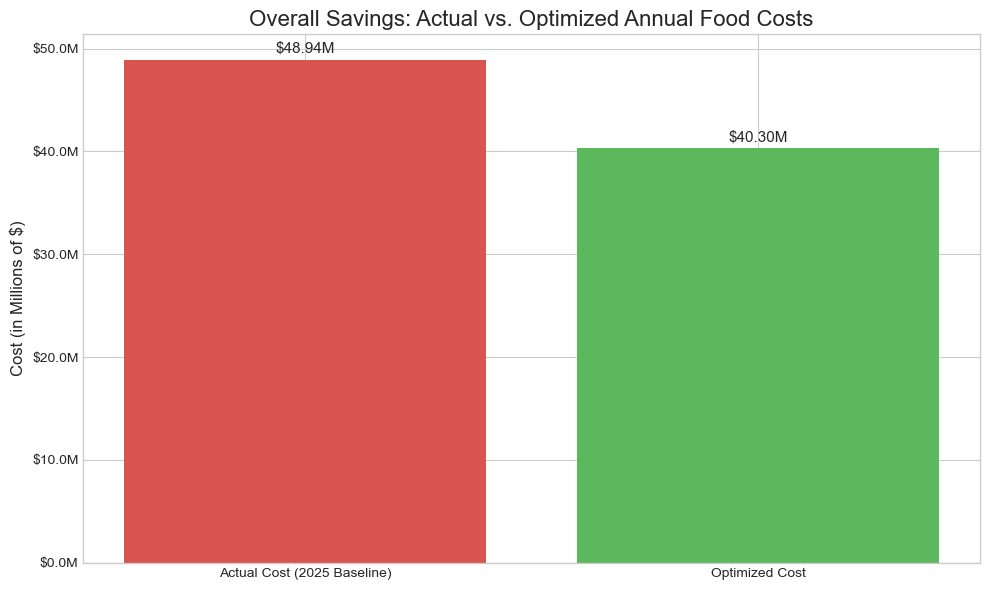


--- Final Savings Summary ---
Total Annual Savings: $8,635,421.92 (17.65%)


In [13]:
if 'monthly_results_df' in locals() and monthly_results_df is not None:
    
    # Get the actual annual cost from 2025 data
    actual_annual_cost = calculate_actual_annual_cost(opt_data)
    
    # --- Calculate the Total Optimized Cost ---
    meal_cost_map = {'Breakfast': monthly_meal_costs[0], 'Lunch': monthly_meal_costs[1]}
    
    results_copy = monthly_results_df.copy()
    results_copy['monthly_food_cost'] = results_copy.apply(
        lambda row: row['optimal_quantity'] * meal_cost_map[row['meal_type']], axis=1
    )
    optimized_monthly_cost = results_copy['monthly_food_cost'].sum()
    optimized_annual_cost = optimized_monthly_cost * 10
    
    # --- Create the Bar Chart ---
    labels = ['Actual Cost (2025 Baseline)', 'Optimized Cost']
    values = [actual_annual_cost, optimized_annual_cost]
    colors = ['#d9534f', '#5cb85c'] # Red for actual, green for optimized
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bars = ax.bar(labels, values, color=colors)
    
    # Add labels and title
    ax.set_title('Overall Savings: Actual vs. Optimized Annual Food Costs', fontsize=16)
    ax.set_ylabel('Cost (in Millions of $)', fontsize=12)
    
    # Format the y-axis to show currency in millions
    ax.get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
    
    # Add data labels on top of the bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'${height/1e6:.2f}M',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # --- Print a final summary ---
    savings = actual_annual_cost - optimized_annual_cost
    savings_percent = (savings / actual_annual_cost) * 100
    print("\n--- Final Savings Summary ---")
    print(f"Total Annual Savings: ${savings:,.2f} ({savings_percent:.2f}%)")


ANALYSIS: Savings by School Size Category


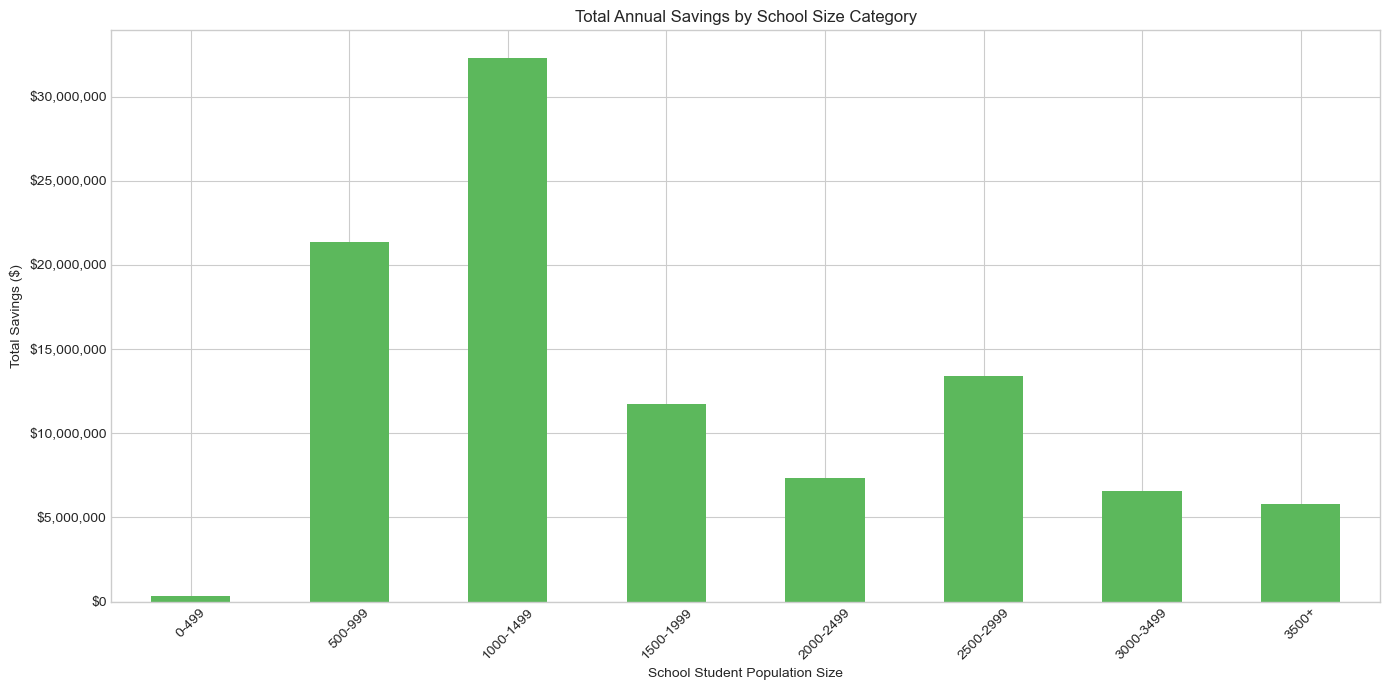

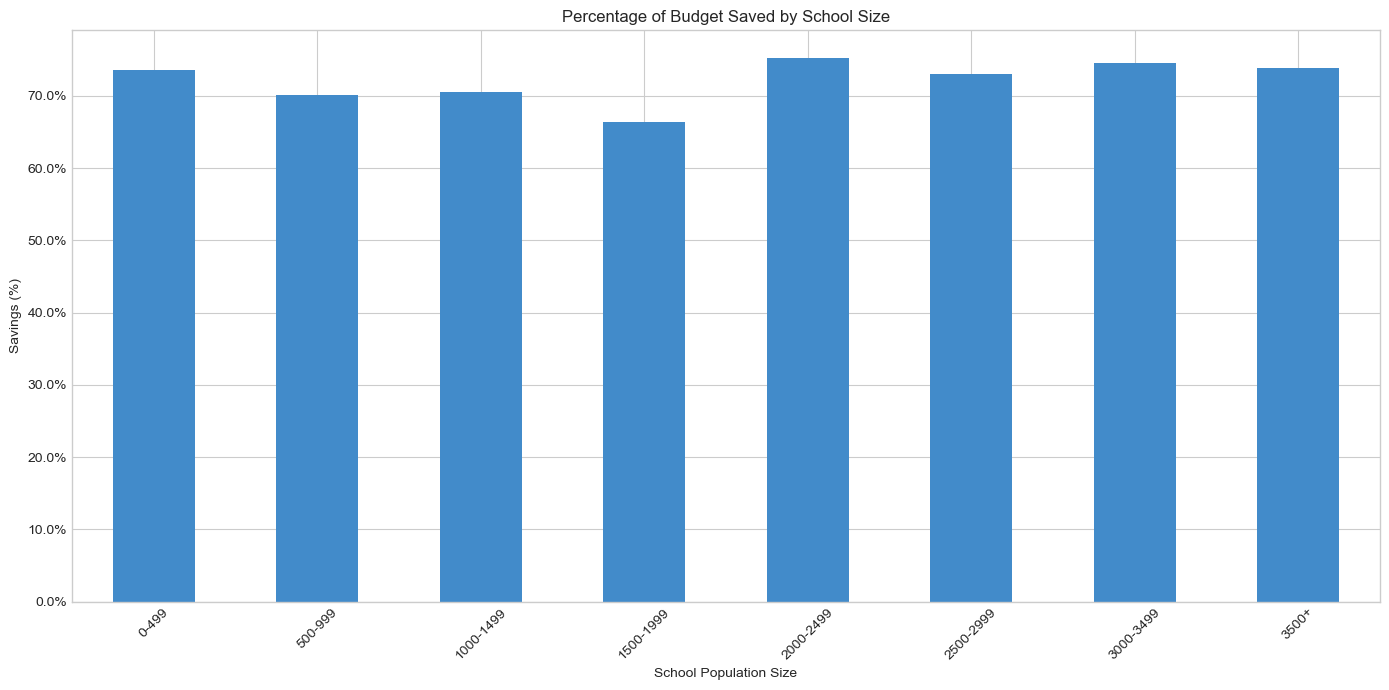

In [14]:
if 'monthly_results_df' in locals() and monthly_results_df is not None:
    # Call the function to get the aggregated data by size
    savings_by_size_df = analyze_savings_by_school_size(
        monthly_results_df,
        monthly_school_budgets,
        monthly_meal_costs,
        opt_data['df_sizes']
    )

    if savings_by_size_df is not None:
        range_map = {
            'xxs': '0-499',
            'xs': '500-999',
            's': '1000-1499',
            'm': '1500-1999',
            'l': '2000-2499',
            'xl': '2500-2999',
            'xxl': '3000-3499',
            'xxxl': '3500+'
        }
        savings_by_size_df['count_range'] = savings_by_size_df['size_category'].map(range_map)
        # Sort by size category for a logical order in the plot
        size_order = ['xxs', 'xs', 's', 'm', 'l', 'xl', 'xxl', 'xxxl']
        savings_by_size_df['size_category'] = pd.Categorical(savings_by_size_df['size_category'], categories=size_order, ordered=True)
        savings_by_size_df = savings_by_size_df.sort_values('size_category')
        
        # --- Total Savings in Dollars ---
        plt.style.use('seaborn-v0_8-whitegrid')
        ax1 = savings_by_size_df.plot(
            x='count_range',
            y='total_savings',
            kind='bar',
            figsize=(14, 7),
            title='Total Annual Savings by School Size Category',
            rot=45,
            legend=False,
            color='#5cb85c'
        )
        ax1.set_xlabel("School Student Population Size")
        ax1.set_ylabel("Total Savings ($)")
        ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        plt.tight_layout()
        plt.show()

        # --- Percentage of Budget Saved ---
        ax2 = savings_by_size_df.plot(
            x='count_range',
            y='percent_savings',
            kind='bar',
            figsize=(14, 7),
            title='Percentage of Budget Saved by School Size',
            rot=45,
            legend=False,
            color='#428bca'
        )
        ax2.set_xlabel("School Population Size")
        ax2.set_ylabel("Savings (%)")
        ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))
        plt.tight_layout()
        plt.show()

In [15]:
if 'monthly_results_df' in locals() and monthly_results_df is not None:
    # Prepare the savings data
    savings_df = prepare_savings_analysis_df(
        opt_data,
        monthly_results_df,
        monthly_meal_costs
    )
    
    # Prepare the map data by merging savings with coordinates
    coordinates_file = '../data/preprocessed-data/data_breakfast_with_coordinates.csv'
    map_df = prepare_map_data_from_coordinates(savings_df, coordinates_file)

    if map_df is not None and not map_df.empty:
        # Create the interactive map
        map_center = [38.83, -77.27]
        m = folium.Map(location=map_center, zoom_start=10)
        
        max_abs_savings = map_df['savings_magnitude'].max()
        def scale_radius(savings_magnitude):
            if savings_magnitude > 0:
                return (savings_magnitude / max_abs_savings)**(1/3) * 20 + 2
            return 2

        # Add a bubble for each school
        for idx, row in map_df.iterrows():
            # Determine color based on outcome
            color = 'green' if row['outcome'] == 'Savings' else 'red'
            
            # Create the popup text
            popup_text = f"<strong>School:</strong> {row['school'].title()}<br>" \
                         f"<strong>Annual Savings:</strong> ${row['savings']:,.2f}"
            
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=scale_radius(row['savings_magnitude']),
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.6,
                popup=folium.Popup(popup_text, max_width=300)
            ).add_to(m)
        
        display(m)


--- Preparing Map Data from Coordinates ---
Successfully merged coordinate data for 190 schools.


In [16]:
def create_savings_map(filtered_df, map_center, level_label):
    max_abs_savings = filtered_df['savings_magnitude'].max()

    def scale_radius(savings_magnitude):
        if savings_magnitude > 0:
            return (savings_magnitude / max_abs_savings) ** (1/3) * 20 + 2
        return 2

    m = folium.Map(location=map_center, zoom_start=10)
    
    for idx, row in filtered_df.iterrows():
        color = 'green' if row['outcome'] == 'Savings' else 'red'
        popup_text = f"<strong>School:</strong> {row['school'].title()}<br>" \
                     f"<strong>Annual Savings:</strong> ${row['savings']:,.2f}"

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=scale_radius(row['savings_magnitude']),
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.6,
            popup=folium.Popup(popup_text, max_width=300)
        ).add_to(m)

    print(f"Displaying map for {level_label} schools:")
    display(m)


In [ ]:
if 'monthly_results_df' in locals() and monthly_results_df is not None:
    # Prepare the savings data
    savings_df = prepare_savings_analysis_df(
        opt_data,
        monthly_results_df,
        monthly_meal_costs
    )

    # Load coordinates file and Level data
    coordinates_file = '../data/preprocessed-data/data_breakfast_with_coordinates.csv'
    coords_df = pd.read_csv(coordinates_file, low_memory=False)
    coords_df.columns = coords_df.columns.str.lower()

    if 'school_name' in coords_df.columns:
        coords_df.rename(columns={'school_name': 'school'}, inplace=True)
    coords_df['school'] = coords_df['school'].str.lower()

    # Ensure 'level' column is present and clean
    if 'level' not in coords_df.columns:
        print("Error: 'level' column not found in coordinates file.")
    else:
        # Merge savings with coordinates + level info
        map_df = pd.merge(savings_df, coords_df[['school', 'latitude', 'longitude', 'level']], on='school', how='inner')
        map_df.dropna(subset=['latitude', 'longitude'], inplace=True)

        # Calculate savings magnitude and outcome if not already
        if 'savings_magnitude' not in map_df.columns:
            map_df['savings_magnitude'] = map_df['savings'].abs()
        if 'outcome' not in map_df.columns:
            map_df['outcome'] = np.where(map_df['savings'] >= 0, 'Savings', 'Loss')

        # Generate maps by school level
        map_center = [38.83, -77.27]

        for level_code, level_label in [('ES', 'Elementary'), ('MS', 'Middle'), ('HS', 'High')]:
            level_df = map_df[map_df['level'] == level_code]
            if not level_df.empty:
                create_savings_map(level_df, map_center, level_label)
            else:
                print(f"No data found for level: {level_label}")


In [ ]:
m, regional_df = generate_fcps_region_choropleth(
    savings_df,
    coords_csv_path="../data/preprocessed-data/data_breakfast_with_coordinates.csv",
    geojson_path="../data/preprocessed-data/School_Regions.geojson"
)

m

In [ ]:
# Merge Level info into savings_df
savings_with_level = pd.merge(savings_df, coords_df[['school', 'level']], on='school', how='left')

# Now filter by level and generate graphs for each
for level in ['ES', 'MS', 'HS']:
    filtered_df = savings_with_level[savings_with_level['level'] == level]
    if filtered_df.empty:
        print(f"No data for level {level}")
        continue

    print(f"\nGenerating graph for {level} schools...")

    # Example: generate region choropleth map for each level
    m, regional_df = generate_fcps_region_choropleth(
        filtered_df,
        coords_csv_path="../data/preprocessed-data/data_breakfast_with_coordinates.csv",
        geojson_path="../data/preprocessed-data/School_Regions.geojson",
        bins=None  # Let folium auto-scale
    )

    display(m)


In [ ]:
print("dfb columns:", dfb.columns.tolist())
print("savings_df columns:", savings_df.columns.tolist())

In [49]:
dfl.columns

Index(['school_name', 'date', 'identifier', 'name', 'planned_reimbursable',
       'planned_non-reimbursable', 'planned_total', 'offered_reimbursable',
       'offered_non-reimbursable', 'offered_total', 'served_reimbursable',
       'served_non-reimbursable', 'served_total', 'discarded_total',
       'discarded_cost', 'subtotal_cost', 'left_over_total',
       'left_over_percent_of_offered', 'left_over_cost',
       'production_cost_total', 'Calories', 'Total Fat (g)',
       'Saturated Fat (g)', 'Cholesterol (mg)', 'Sodium (mg)',
       'Carbohydrate (g)', 'Dietary Fiber (g)', 'Total Sugars (g)',
       'Added Sugars (g)', 'Protein (g)', 'Vitamin A (IU)', 'Vitamin C (mg)',
       'Vitamin D (D2 + D3) (mcg)', 'Calcium (mg)', 'Iron (mg)',
       'Potassium (mg)', 'Category', 'Sub-Category', 'Served'],
      dtype='object')

In [14]:
OPTIMIZATION_FILE = '../data/school_food_item_optimization.csv'
COST_FILE = '../data/unit_costs.csv'
COORDINATES_FILE = '../data/preprocessed-data/data_breakfast_with_coordinates.csv'
LOGO_FILE = '../../demo/fcps_logo2.png'
BREAKFAST_FILE = '../data/preprocessed-data/breakfast_combined.csv'
LUNCH_FILE = '../data/preprocessed-data/lunch_combined.csv'


SCHOOL_TO_TEST = 'annandale high'
OUTPUT_PDF = f"recommendation_for_{SCHOOL_TO_TEST.replace(' ', '_')}.pdf"

# --- Load All Data ---
try:
    df_opt = pd.read_csv(OPTIMIZATION_FILE, low_memory=False)
    df_costs = pd.read_csv(COST_FILE, low_memory=False)
    df_coords = pd.read_csv(COORDINATES_FILE, low_memory=False)
    df_breakfast = pd.read_csv(BREAKFAST_FILE, usecols=['Name', 'Identifier'], encoding='latin-1', dtype={'Identifier': str})
    df_lunch = pd.read_csv(LUNCH_FILE, usecols=['Name', 'Identifier'], encoding='latin-1', dtype={'Identifier': str})

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("File not found. Please check your relative paths and ensure the script is running from the correct directory.")
except Exception as e:
    print(f"An error occurred loading files: {e}")
else:
    # --- Create Identifier and Averaged Cost Lookup Tables ---

    df_ids = pd.concat([df_breakfast, df_lunch])
    df_ids['food_item_clean'] = df_ids['Name'].str.strip().str.lower()
    df_ids = df_ids.drop_duplicates(subset=['food_item_clean'])
    df_ids = df_ids[['food_item_clean', 'Identifier']]

    # ID Override Map for merging items like different milk types
    id_override_map = {
        'fat free white milk (each)': '20001', 
    }
    def apply_override(row):
        return id_override_map.get(row['food_item_clean'], row['Identifier'])
    df_ids['Identifier'] = df_ids.apply(apply_override, axis=1)
    df_ids_cost_map = df_ids.set_index('food_item_clean')['Identifier']

    # Prepare costs and average by identifier
    df_costs['Name_clean'] = df_costs['Name'].str.strip().str.lower()
    df_costs['Identifier'] = df_costs['Name_clean'].map(df_ids_cost_map)
    df_costs_with_ids = df_costs.dropna(subset=['Identifier'])
    df_costs_avg = df_costs_with_ids.groupby('Identifier', as_index=False)['Unit_Cost'].mean()
    print(f"Averaged costs for {len(df_costs_avg)} unique identifiers.")

    # Create a School Information Lookup Table
    school_info_cols = ['Normalized_School_Name_excel', 'address']
    df_school_info = df_coords[school_info_cols].copy()
    df_school_info.columns = ['school_clean', 'address']
    df_school_info = df_school_info.drop_duplicates(subset=['school_clean']).set_index('school_clean')

    # --- Clean and Prepare Data ---

    def normalize_school_for_lookup(name):
        if not isinstance(name, str): return name
        name = re.sub(r'\s+', ' ', name).strip().lower()
        replacements = {
            ' elementary': ' es',
            ' middle': ' ms',
            ' high': ' hs',
            ' secondary': ' ss',
            ' school': ''
        }
        for old, new in replacements.items(): name = name.replace(old, new)
        return name

    df_opt['school_clean'] = df_opt['school'].apply(normalize_school_for_lookup)
    df_opt['food_item_clean'] = df_opt['food_item'].str.strip().str.lower()

    # --- Get Specific Info for the Selected School ---
    school_clean_name = normalize_school_for_lookup(SCHOOL_TO_TEST)
    try:
        school_address = df_school_info.loc[school_clean_name, 'address']
    except KeyError:
        print(f"Warning: Could not find address info for '{school_clean_name}'. Using defaults.")
        school_address = "Address Not Found"

    # --- Filter, Aggregate, and Merge ---
    df_school = df_opt[df_opt['school_clean'] == school_clean_name].copy()

    if df_school.empty:
        print(f"Error: No optimization data found for school: '{SCHOOL_TO_TEST}'")
    else:
        # Merge school data with identifiers
        df_school_with_ids = pd.merge(df_school, df_ids, on='food_item_clean', how='left')

        # Separate mapped and unmapped items
        df_mapped = df_school_with_ids.dropna(subset=['Identifier'])
        df_unmapped = df_school_with_ids[df_school_with_ids['Identifier'].isna()]

        # Aggregation logic with conditional name cleaning
        id_variation_counts = df_mapped.groupby('Identifier')['food_item_clean'].nunique()
        df_agg_mapped = df_mapped.groupby('Identifier', as_index=False).agg(
            food_item=('food_item', 'first'),
            recommended_quantity=('recommended_quantity', 'sum')
        )
        df_agg_mapped = pd.merge(df_agg_mapped, id_variation_counts.rename('variation_count'), on='Identifier')
        
        def clean_name_conditionally(row):
            if row['variation_count'] > 1:
                return re.sub(r'\s*\(.*\)', '', row['food_item']).strip()
            else:
                return row['food_item']

        df_agg_mapped['food_item'] = df_agg_mapped.apply(clean_name_conditionally, axis=1)
        df_agg_mapped = df_agg_mapped.drop(columns=['variation_count'])
        
        # "Aggregate" UNMAPPED items by their name
        df_agg_unmapped = df_unmapped.groupby('food_item_clean', as_index=False).agg(
             food_item=('food_item', 'first'),
             recommended_quantity=('recommended_quantity', 'sum'),
             Identifier=('Identifier', 'first')
        )

        # Combine the two groups
        df_school_agg = pd.concat([df_agg_mapped, df_agg_unmapped], ignore_index=True)

        # Merge with averaged costs
        df_order_list = pd.merge(df_school_agg, df_costs_avg, on='Identifier', how='left')
        df_order_list['Identifier'] = df_order_list['Identifier'].fillna('N/A')

        # --- Calculate Total Cost & Format ---
        df_order_list['Unit_Cost'] = df_order_list['Unit_Cost'].fillna(0)
        df_order_list['Total_Cost'] = df_order_list['recommended_quantity'] * df_order_list['Unit_Cost']

        df_final_report = df_order_list[['Identifier', 'food_item', 'Unit_Cost', 'recommended_quantity', 'Total_Cost']]

        df_final_report = df_final_report.rename(columns={
            'Identifier': 'ID', 'food_item': 'Food Item', 'Unit_Cost': 'Cost',
            'recommended_quantity': 'Qty', 'Total_Cost': 'Total'
        })

        df_final_report = df_final_report.sort_values(by='Food Item').reset_index(drop=True)
        df_final_report['Food Item'] = df_final_report['Food Item'].str.replace("’", "'").str.replace("–", "-").str.replace("—", "-")
        
        production_cost_total = df_final_report['Total'].sum()

        # --- Generate PDF ---

        class PDF(FPDF):
            def __init__(self, orientation='P', unit='mm', format='Letter', school_address='N/A'):
                super().__init__(orientation, unit, format)
                self.school_address = school_address
                self.set_auto_page_break(auto=True, margin=15)
                self.column_widths = []
                self.table_headers = []
                self.start_x_table = self.l_margin


            def header(self):
                if self.page_no() == 1:
                    self.set_font('Times', 'B', 16)
                    self.set_xy(10, 15)
                    self.cell(120, 10, 'Food Order Recommendation Form', 0, new_x=XPos.LMARGIN, new_y=YPos.NEXT, align='L')
                    try:
                        page_width, logo_width, right_margin = self.w, 30, 10
                        logo_x = page_width - logo_width - right_margin
                        self.image(LOGO_FILE, x=logo_x, y=8, w=logo_width)
                    except RuntimeError as e:
                        print(f"Error adding logo: {e}.")
                        self.rect(logo_x, 8, logo_width, 20, 'D'); self.set_xy(logo_x, 15); self.cell(logo_width, 5, "No Logo", 0, new_x=XPos.RIGHT, new_y=YPos.TOP, align='C')

                    box_y, box_x_left, box_w_left = 25, 10, 90
                    self.set_font('Times', 'B', 10)
                    self.set_fill_color(220, 220, 220)
                    self.set_xy(box_x_left, box_y)
                    self.cell(box_w_left, 7, 'Recommendation for', border='TLR', new_x=XPos.LMARGIN, new_y=YPos.NEXT, align='L', fill=True)

                    self.set_font('Times', '', 9)
                    try:
                        parts = self.school_address.split(',', 1)
                        recommendation_text = f"  {SCHOOL_TO_TEST.title()}\n  {parts[0].strip()}\n  {parts[1].strip()}"
                    except Exception:
                        recommendation_text = f"  {SCHOOL_TO_TEST.title()}\n  {self.school_address}"

                    self.set_x(box_x_left)
                    self.multi_cell(box_w_left, 5, recommendation_text, border='LRB', align='L')
                    y_box_end_left = self.get_y()

                    box_x_right, box_w_right = 105, 45
                    self.set_font('Times', 'B', 10)
                    self.set_fill_color(220, 220, 220)
                    self.set_xy(box_x_right, box_y)
                    self.cell(box_w_right, 7, 'Generated', border='TLR', new_x=XPos.LMARGIN, new_y=YPos.NEXT, align='L', fill=True)

                    self.set_font('Times', '', 9)
                    self.set_x(box_x_right)
                    self.multi_cell(box_w_right, 5, f"  {datetime.now().strftime('%B %d, %Y')}", border='LRB', align='L')
                    y_box_end_right = self.get_y()

                    self.set_y(max(y_box_end_left, y_box_end_right) + 8)
                
                elif self.page_no() > 1:
                    self.set_font('Times', 'B', 10)
                    self.set_fill_color(200, 220, 255)
                    self.set_x(self.start_x_table)
                    for i, header in enumerate(self.table_headers):
                        self.cell(self.column_widths[i], 7, header, 1, new_x=XPos.RIGHT, new_y=YPos.TOP, align='C', fill=True)
                    self.ln()


            def footer(self):
                self.set_y(-15)
                self.set_font('Times', 'I', 8)
                self.cell(0, 10, f'Page {self.page_no()}', 0, new_x=XPos.RIGHT, new_y=YPos.TOP, align='C')

            def create_table(self, data, column_widths, production_total):
                self.column_widths = column_widths
                self.table_headers = list(data.columns)
                self.start_x_table = self.l_margin
                table_width = sum(column_widths)

                # Draw headers on the FIRST page
                self.set_font('Times', 'B', 10)
                self.set_fill_color(200, 220, 255)
                self.set_x(self.start_x_table)
                for i, header in enumerate(self.table_headers):
                    self.cell(self.column_widths[i], 7, header, 1, new_x=XPos.RIGHT, new_y=YPos.TOP, align='C', fill=True)
                self.ln()

                self.set_font('Times', '', 9)
                self.set_fill_color(255)
                fill = False

                for _, row in data.iterrows():
                    # Page break check
                    if self.get_y() + 6 > self.h - 15:
                        self.set_x(self.start_x_table)
                        self.cell(table_width, 0, '', 'T')
                        self.add_page(self.cur_orientation)
                        self.set_font('Times', '', 9)
                        self.set_fill_color(255)
                        fill = False
                    
                    self.set_x(self.start_x_table)
                    start_x, start_y = self.get_x(), self.get_y()
                    
                    food_item_x = start_x + column_widths[0]
                    
                    self.set_xy(food_item_x, start_y)
                    self.multi_cell(column_widths[1], 6, str(row['Food Item']), 'LR', 'L', fill=fill)
                    row_height = self.get_y() - start_y
                    
                    self.set_xy(start_x, start_y)
                    self.cell(column_widths[0], row_height, str(row['ID']), 'LR', new_x=XPos.RIGHT, new_y=YPos.TOP, align='L', fill=fill)
                    
                    self.set_xy(food_item_x + column_widths[1], start_y)
                    self.cell(column_widths[2], row_height, f"${row['Cost']:,.2f}", 'LR', new_x=XPos.RIGHT, new_y=YPos.TOP, align='R', fill=fill)
                    self.cell(column_widths[3], row_height, str(int(row['Qty'])), 'LR', new_x=XPos.RIGHT, new_y=YPos.TOP, align='R', fill=fill)
                    self.cell(column_widths[4], row_height, f"${row['Total']:,.2f}", 'LR', new_x=XPos.RIGHT, new_y=YPos.TOP, align='R', fill=fill)
                    
                    self.set_y(start_y + row_height)
                    fill = not fill

                # Closing line and total
                self.set_x(self.start_x_table)
                self.cell(table_width, 0, '', 'T')
                self.ln(2)
    
                label_width = sum(column_widths[:4])
                value_width = column_widths[4]
                
                self.set_x(self.start_x_table)
                self.set_font('Times', 'B', 10)
                self.cell(label_width, 7, 'Production Cost Total', 0, new_x=XPos.RIGHT, new_y=YPos.TOP, align='R')
                self.set_fill_color(240, 240, 240)
                self.cell(value_width, 7, f"${production_total:,.2f}", 1, new_x=XPos.LMARGIN, new_y=YPos.NEXT, align='R', fill=True)


        # Create and Save the PDF
        pdf = PDF('P', 'mm', 'Letter', school_address)
        pdf.add_page()
        
        # (ID, Food Item, Cost, Qty, Total)
        col_widths = [20, 120, 20, 15, 21]

        pdf.create_table(df_final_report, col_widths, production_cost_total)

        try:
            pdf.output(OUTPUT_PDF)
            print(f"\nSuccessfully generated Professional PDF: {OUTPUT_PDF}")
        except Exception as e:
            print(f"\nError saving PDF: {e}")

Averaged costs for 329 unique identifiers.

Successfully generated Professional PDF: recommendation_for_annandale_high.pdf


# Milk Optimization

In [38]:
# add in nutrition file
nutrition = pd.read_csv("../data/preprocessed-data/fcps_nutrition_values.csv")
nutrition.rename(columns={'Food_Name': 'name'}, inplace=True)

# add column to dfb/dfl
dfb = dfb.merge(nutrition, on='name', how='left')
dfl = dfl.merge(nutrition, on='name', how='left')

In [39]:
# create milk files
milk_b = dfb[dfb['Sub-Category'] == 'Milk']
milk_l = dfl[dfl['Sub-Category'] == 'Milk']

In [40]:
# save files as csv
milk_b.to_csv('../data/preprocessed-data/milk_b.csv', index=False)
milk_l.to_csv('../data/preprocessed-data/milk_l.csv', index=False)

In [41]:
# Define file paths
breakfast_milk_file = '../data/preprocessed-data/milk_b.csv'
lunch_milk_file = '../data/preprocessed-data/milk_b.csv'
student_counts_file = '../data/preprocessed-data/2022-2025 Fairfax County School Student Count.csv'

# Prepare all data needed for the optimization models
opt_data_milk = prepare_optimization_data_m(breakfast_milk_file, lunch_milk_file, student_counts_file)

--- Preparing Optimization Data ---
Data preparation complete.


In [42]:
if opt_data_milk:
    # Set up parameters for this specific scenario
    total_budget = 139144760
    budget_per_school = total_budget / len(opt_data_milk['schools'])
    school_budgets = {s: budget_per_school for s in opt_data_milk['schools']}
    waste_penalty = [0.50, 1.00]

    daily_bounds = []
    for school in opt_data_milk['schools']:
        for i in range(len(opt_data_milk['meal_types'])):
            daily_bounds.append((opt_data_milk['demand'][school][i] * 0.90, opt_data_milk['demand'][school][i] * 1.10))

    # Run the optimization and generate the item breakdown
    results_df = run_meal_optimization_m(
        opt_data_milk['schools'], opt_data_milk['meal_types'], opt_data_milk['meal_costs'], 
        opt_data_milk['demand'], school_budgets, total_budget, waste_penalty, daily_bounds
    )
    generate_item_breakdown_m(results_df, milk_b, milk_l, '../data/school_milk_optimization.csv')


--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $14102.47

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 42 units (Demand: 47, Prod. Bounds: 42-52)
    Lunch: 42 units (Demand: 47, Prod. Bounds: 42-52)
    School Total Cost: $48.56 (Budget: $732340.84)

  annandale high:
    Breakfast: 132 units (Demand: 148, Prod. Bounds: 132-162)
    Lunch: 132 units (Demand: 148, Prod. Bounds: 132-162)
    School Total Cost: $152.63 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 129 units (Demand: 144, Prod. Bounds: 129-158)
    Lunch: 129 units (Demand: 144, Prod. Bounds: 129-158)
    School Total Cost: $149.16 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 32 units (Demand: 36, Prod. Bounds: 32-39)
    Lunch: 32 units (Demand: 36, Prod. Bounds: 32-39)
    School Total Cost: $37.00 (Budget: $732340.84)

  baileys lower elementary:
    Breakfast: 243 units (Deman

In [43]:
if opt_data_milk and opt_data_milk['all_school_lists']:
    run_size_based_optimization_m(
        opt_data_milk['schools'], opt_data_milk['meal_types'], opt_data_milk['meal_costs'],
        opt_data_milk['demand'], {s: (139144760 / len(opt_data_milk['schools'])) for s in opt_data_milk['schools']}, 
        36362814, [0.50, 1.00], opt_data_milk['all_school_lists']
    )

--- Starting Size-Based Optimization ---
Categorized 190 schools based on your lists.
Production bounds have been set based on custom school sizes.

--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $14109.32

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 40 units (Demand: 47, Prod. Bounds: 40-54)
    Lunch: 40 units (Demand: 47, Prod. Bounds: 40-54)
    School Total Cost: $46.25 (Budget: $732340.84)

  annandale high:
    Breakfast: 143 units (Demand: 148, Prod. Bounds: 143-152)
    Lunch: 143 units (Demand: 148, Prod. Bounds: 143-152)
    School Total Cost: $165.35 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 129 units (Demand: 144, Prod. Bounds: 129-158)
    Lunch: 129 units (Demand: 144, Prod. Bounds: 129-158)
    School Total Cost: $149.16 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 30 units (Demand: 36, Prod. Bounds: 30-41)
    Lunch: 30 uni

c:\Users\kaoji\OneDrive\Documents\Grad School\6501-Capstone\fall-2025-group2\src\component\optimization_milk.py:345: DtypeWarning:

Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.



In [44]:
# Load your optimized results (or use the already available DataFrame)
df = pd.read_csv('../data/school_milk_optimization_by_size.csv')

# Filter for only milk items (if needed)
milk_df = df[df['food_item'].str.lower().str.contains('milk')]

# Sum milk across breakfast + lunch per school
milk_by_school = milk_df.groupby('school')['recommended_quantity'].sum().reset_index()
milk_by_school = milk_by_school.sort_values('recommended_quantity', ascending=False)

# Create a horizontal bar chart
fig = px.bar(
    milk_by_school,
    x='recommended_quantity',
    y='school',
    orientation='h',
    title='Total Milk Count per School (Breakfast + Lunch)',
    labels={'recommended_quantity': 'Milk Count', 'school': 'School'},
    height=800  # adjust height depending on number of schools
)

# Make the Y-axis scrollable by limiting number of visible bars
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    margin=dict(l=150, r=30, t=50, b=30),
    height=1000,
)

fig.show()